In [1]:
import kagglehub, os, random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import ResNet50, EfficientNetB3
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

path = kagglehub.dataset_download("sartajbhuvaji/brain-tumor-classification-mri")
TRAIN_DIR = os.path.join(path, "Training")
TEST_DIR  = os.path.join(path, "Testing")
CLASS_NAMES = sorted(os.listdir(TRAIN_DIR))
print("Classes:", CLASS_NAMES)

Using Colab cache for faster access to the 'brain-tumor-classification-mri' dataset.
Classes: ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']


In [2]:
IMG_SIZE   = (224, 224)  # Increased resolution for higher feature clarity
BATCH_SIZE = 32          # Decreased batch size slightly to accommodate larger images in GPU memory

train_gen = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

val_gen = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

test_gen = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=False
)

NUM_CLASSES = len(CLASS_NAMES)

# Enhanced Augmentation Layer
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
])

AUTOTUNE = tf.data.AUTOTUNE
train_gen = train_gen.prefetch(buffer_size=AUTOTUNE) # Removed .map(lambda x, y: (data_augmentation(x, training=True), y), num_parallel_calls=AUTOTUNE)
val_gen = val_gen.prefetch(buffer_size=AUTOTUNE)
test_gen = test_gen.prefetch(buffer_size=AUTOTUNE)

Found 2870 files belonging to 4 classes.
Using 2296 files for training.
Found 2870 files belonging to 4 classes.
Using 574 files for validation.
Found 394 files belonging to 4 classes.


In [3]:
def build_resnet50():
    inputs = layers.Input(shape=(*IMG_SIZE, 3))
    preprocessed = tf.keras.applications.resnet50.preprocess_input(inputs)
    base = ResNet50(weights='imagenet', include_top=False, input_tensor=preprocessed)
    base.trainable = False
    x = base.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    out = layers.Dense(NUM_CLASSES, activation='softmax')(x)
    return Model(inputs=inputs, outputs=out, name="ResNet50")

loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1)

def build_efficientnet():
    base = EfficientNetB3(weights='imagenet', include_top=False, input_shape=(*IMG_SIZE, 3))
    base.trainable = False
    x = base.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    out = layers.Dense(NUM_CLASSES, activation='softmax')(x)
    return Model(inputs=base.input, outputs=out, name="EfficientNetB3")

In [4]:
callbacks = [
    EarlyStopping(patience=10, restore_best_weights=True, monitor='val_accuracy'),
    ReduceLROnPlateau(patience=2, factor=0.2, monitor='val_loss', verbose=1)
]

from sklearn.utils.class_weight import compute_class_weight
all_labels = np.concatenate([np.argmax(y, axis=1) for x, y in train_gen])
class_weights = compute_class_weight('balanced', classes=np.unique(all_labels), y=all_labels)
class_weight_dict = dict(enumerate(class_weights))
print("Class weights:", class_weight_dict)

def train_model(model):
    name = model.name
    #Warm-up
    print(f"\n{'='*50}\nPhase 1: {name} — Frozen Base (Warmup)\n{'='*50}")
    model.compile(optimizer=Adam(1e-3), loss='categorical_crossentropy', metrics=['accuracy'])
    h1 = model.fit(train_gen, validation_data=val_gen, epochs=12,
                   callbacks=callbacks, class_weight=class_weight_dict)
    #fine-tuning
    print(f"\n{'='*50}\nPhase 2: {name} — Unfreezing Top 30 Layers\n{'='*50}")
    for layer in model.layers[-30:]:
        layer.trainable = True

    model.compile(optimizer=Adam(1e-5), loss='categorical_crossentropy', metrics=['accuracy'])
    h2 = model.fit(train_gen, validation_data=val_gen, epochs=10,
                   callbacks=callbacks, class_weight=class_weight_dict)   # ← add this

    merged = {}
    for k in h1.history:
        merged[k] = h1.history[k] + h2.history[k]
    return model, merged

resnet, h_resnet         = train_model(build_resnet50())
efficientnet, h_efficient = train_model(build_efficientnet())

histories = {"ResNet50": h_resnet, "EfficientNetB3": h_efficient}
models    = {"ResNet50": resnet,   "EfficientNetB3": efficientnet}

Class weights: {0: np.float64(0.8670694864048338), 1: np.float64(0.875), 2: np.float64(1.8222222222222222), 3: np.float64(0.8657616892911011)}

Phase 1: ResNet50 — Frozen Base (Warmup)
Epoch 1/12
72/72 ━━━━━━━━━━━━━━━━━━━━ 38s 320ms/step - accuracy: 0.7535 - loss: 0.7979 - val_accuracy: 0.8136 - val_loss: 0.4805 - learning_rate: 0.0010
Epoch 2/12
72/72 ━━━━━━━━━━━━━━━━━━━━ 7s 101ms/step - accuracy: 0.8776 - loss: 0.3388 - val_accuracy: 0.8641 - val_loss: 0.3592 - learning_rate: 0.0010
Epoch 3/12
72/72 ━━━━━━━━━━━━━━━━━━━━ 8s 104ms/step - accuracy: 0.9116 - loss: 0.2240 - val_accuracy: 0.8920 - val_loss: 0.3313 - learning_rate: 0.0010
Epoch 4/12
72/72 ━━━━━━━━━━━━━━━━━━━━ 10s 107ms/step - accuracy: 0.9321 - loss: 0.1833 - val_accuracy: 0.9059 - val_loss: 0.2830 - learning_rate: 0.0010
Epoch 5/12
72/72 ━━━━━━━━━━━━━━━━━━━━ 7s 102ms/step - accuracy: 0.9482 - loss: 0.1432 - val_accuracy: 0.8990 - val_loss: 0.3432 - learning_rate: 0.0010
Epoch 6/12
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - 


ResNet50
  Accuracy  : 0.7411
  Precision : 0.8264
  Recall    : 0.7376
  F1        : 0.7153

                   precision    recall  f1-score   support

    glioma_tumor       0.96      0.24      0.38       100
meningioma_tumor       0.65      0.94      0.77       115
        no_tumor       0.70      0.93      0.80       105
 pituitary_tumor       1.00      0.84      0.91        74

        accuracy                           0.74       394
       macro avg       0.83      0.74      0.72       394
    weighted avg       0.81      0.74      0.71       394



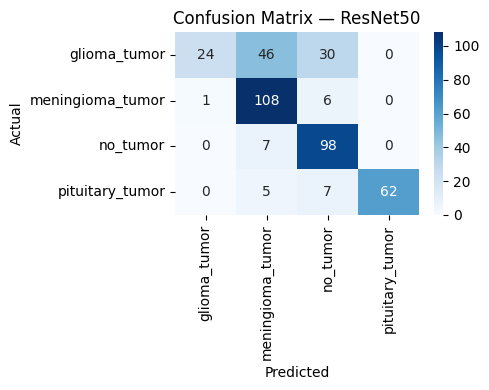


EfficientNetB3
  Accuracy  : 0.7208
  Precision : 0.7419
  Recall    : 0.7144
  F1        : 0.7105

                   precision    recall  f1-score   support

    glioma_tumor       0.75      0.41      0.53       100
meningioma_tumor       0.63      0.86      0.73       115
        no_tumor       0.77      0.86      0.81       105
 pituitary_tumor       0.82      0.73      0.77        74

        accuracy                           0.72       394
       macro avg       0.74      0.71      0.71       394
    weighted avg       0.73      0.72      0.71       394



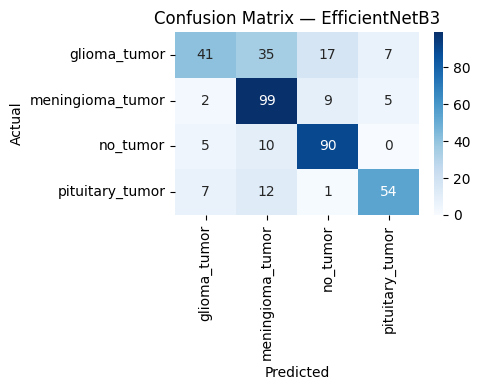

In [8]:
def evaluate(model, name):
    y_true = np.concatenate([y for x, y in test_gen], axis=0)
    y_true = np.argmax(y_true, axis=1)

    y_pred = np.argmax(model.predict(test_gen, verbose=0), axis=1)

    metrics = {
        "accuracy":       accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, average='macro', zero_division=0),
        "recall":    recall_score(y_true, y_pred, average='macro', zero_division=0),
        "f1":        f1_score(y_true, y_pred, average='macro', zero_division=0),
    }
    print(f"\n{'='*50}\n{name}\n{'='*50}")
    for k, v in metrics.items():
        print(f"  {k.capitalize():<10}: {v:.4f}")
    print("\n", classification_report(y_true, y_pred, target_names=CLASS_NAMES))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.title(f'Confusion Matrix — {name}')
    plt.ylabel('Actual'); plt.xlabel('Predicted')
    plt.tight_layout(); plt.show()
    return metrics

all_metrics = {name: evaluate(model, name) for name, model in models.items()}

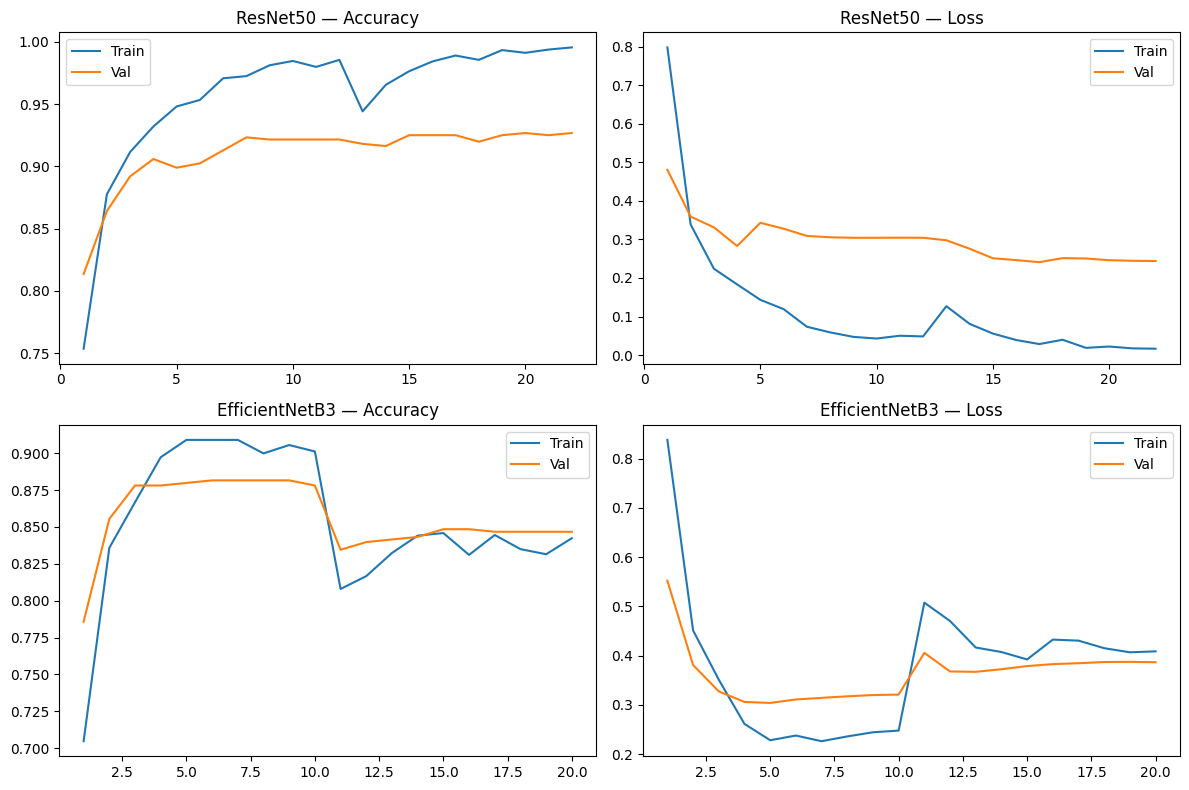

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for i, (name, h) in enumerate(histories.items()):
    ep = range(1, len(h['accuracy']) + 1)
    axes[i, 0].plot(ep, h['accuracy'],     label='Train'); axes[i, 0].plot(ep, h['val_accuracy'], label='Val')
    axes[i, 0].set_title(f'{name} — Accuracy'); axes[i, 0].legend()
    axes[i, 1].plot(ep, h['loss'],         label='Train'); axes[i, 1].plot(ep, h['val_loss'],     label='Val')
    axes[i, 1].set_title(f'{name} — Loss');     axes[i, 1].legend()
plt.tight_layout(); plt.show()

In [7]:
print(f"\n{'Model':<18} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1':>10}")
print("="*55)
for name, m in all_metrics.items():
    print(f"{name:<18} {m['acc']:>10.4f} {m['precision']:>10.4f} {m['recall']:>10.4f} {m['f1']:>10.4f}")


Model                Accuracy  Precision     Recall         F1
ResNet50               0.7411     0.8264     0.7376     0.7153
EfficientNetB3         0.7208     0.7419     0.7144     0.7105
